In [272]:
import importlib
import ToFPipeline
import pandas as pd

In [273]:
importlib.reload(ToFPipeline)
ToFPipeline.GlobalConfig.load("config.yaml")
runNo=1999

In [274]:
raw = """
> |Photon Energy|daq_run|Ugap|Ushift
> |1300|2119|29.673|14
> |1300|2120|28.224|17
> |1300|2121|26.669|20
> |1300|2122|25.169|23
> |1290|2123|29.575|14
> |1290|2124|28.13|17
> |1290|2125|26.579|20
> |1290|2126|25.083|23
> |1280|2127|29.478|14
> |1280|2128|28.034|17
> |1280|2129|26.489|20
> |1280|2130|24.999|23
> |1270|2131|29.378|14
> |1270|2132|27.938|17
> |1270|2133|26.399|20
> |1270|2134|24.913|23
> |1260|2135|29.28|14
> |1260|2136|27.843|17
> |1260|2137|26.308|20
> |1260|2138|24.827|23
> |1250|2139|29.179|14
> |1250|2140|27.747|17
> |1250|2141|26.216|20
> |1250|2142|24.741|23
> |1240|2143|29.079|14
> |1240|2144|27.649|17
> |1240|2145|26.124|20
> |1240|2146|24.655|23
> |1230|2147|28.979|14
> |1230|2148|27.552|17
> |1230|2149|26.03|20
> |1230|2150|24.567|23
> |1230|2152|28.979|14
> |1230|2153|27.552|17
> |1230|2154|26.03|20
> |1230|2155|24.567|23
> |1220|2156|28.878|14
> |1220|2157|27.454|17
> |1220|2158|25.938|20
> |1220|2159|24.479|23
> |1210|2160|28.776|14
> |1210|2161|27.356|17
> |1210|2162|25.845|20
> |1210|2163|24.392|23
> |1200|2164|28.673|14
> |1200|2165|27.257|17
> |1200|2166|25.751|20
> |1200|2167|24.304|23
> |1190|2168|28.569|14
> |1190|2169|27.157|17
> |1190|2170|25.655|20
> |1190|2171|24.216|23
> |1180|2172|28.466|14
> |1180|2173|27.058|17
> |1180|2174|25.56|20
> |1180|2175|24.126|23
> |1170|2176|28.362|14
> |1170|2177|26.956|17
> |1170|2178|25.464|20
> |1170|2179|24.036|23
> |1160|2180|28.257|14
> |1160|2181|26.854|17
> |1160|2182|25.368|20
> |1160|2183|23.946|23
> |1150|2184|28.151|14
> |1150|2185|26.753|17
> |1150|2186|25.271|20
> |1150|2187|23.854|23
> |1140|2188|28.046|14
> |1140|2189|26.651|17
> |1140|2190|25.175|20
> |1140|2191|23.763|23
> |1130|2192|27.938|14
> |1130|2193|26.548|17
> |1130|2194|25.075|20
> |1130|2195|23.671|23
> |1120|2196|27.831|14
> |1120|2197|26.444|17
> |1120|2198|24.978|20
> |1120|2199|23.579|23
> |1110|2200|27.722|14
> |1110|2201|26.341|17
> |1110|2202|24.878|20
> |1110|2203|23.485|23
> |1100|2204|27.614|14
> |1100|2205|26.235|17
> |1100|2206|24.778|20
> |1100|2207|23.392|23
> |1090|2208|27.503|14
> |1090|2209|26.13|17
> |1090|2210|24.679|20
> |1090|2211|23.298|23
> |1080|2212|27.394|14
> |1080|2213|26.022|17
> |1080|2214|24.577|20
> |1080|2215|23.204|23
> |1070|2216|27.282|14
> |1070|2217|25.915|17
> |1070|2218|24.476|20
> |1070|2219|23.108|23
> |1060|2220|27.171|14
> |1060|2221|25.808|17
> |1060|2222|24.374|20
> |1060|2223|23.013|23
> |1050|2224|27.058|14
> |1050|2225|25.7|17
> |1050|2226|24.271|20
> |1050|2227|22.915|23
> |1040|2228|26.944|14
> |1040|2229|25.591|17
> |1040|2230|24.167|20
> |1040|2231|22.819|23
> |1030|2232|26.829|14
> |1030|2233|25.479|17
> |1030|2234|24.062|20
> |1030|2235|22.72|23
> |1020|2236|26.714|14
> |1020|2237|25.37|17
> |1020|2238|23.958|20
> |1020|2239|22.622|23
> |1010|2240|26.599|14
> |1010|2241|25.257|17
> |1010|2242|23.851|20
> |1010|2243|22.522|23
> |1000|2244|26.481|14
> |1000|2245|25.146|17
> |1000|2246|23.745|20
> |1000|2247|22.423|23
"""

In [275]:
data = ToFPipeline.NXSLoader("data").load(runNumbers=[runNo]).defaultPreprocessing(baselineRegion=[1800,1850])

Random trainId: 1999, pulseId: 0


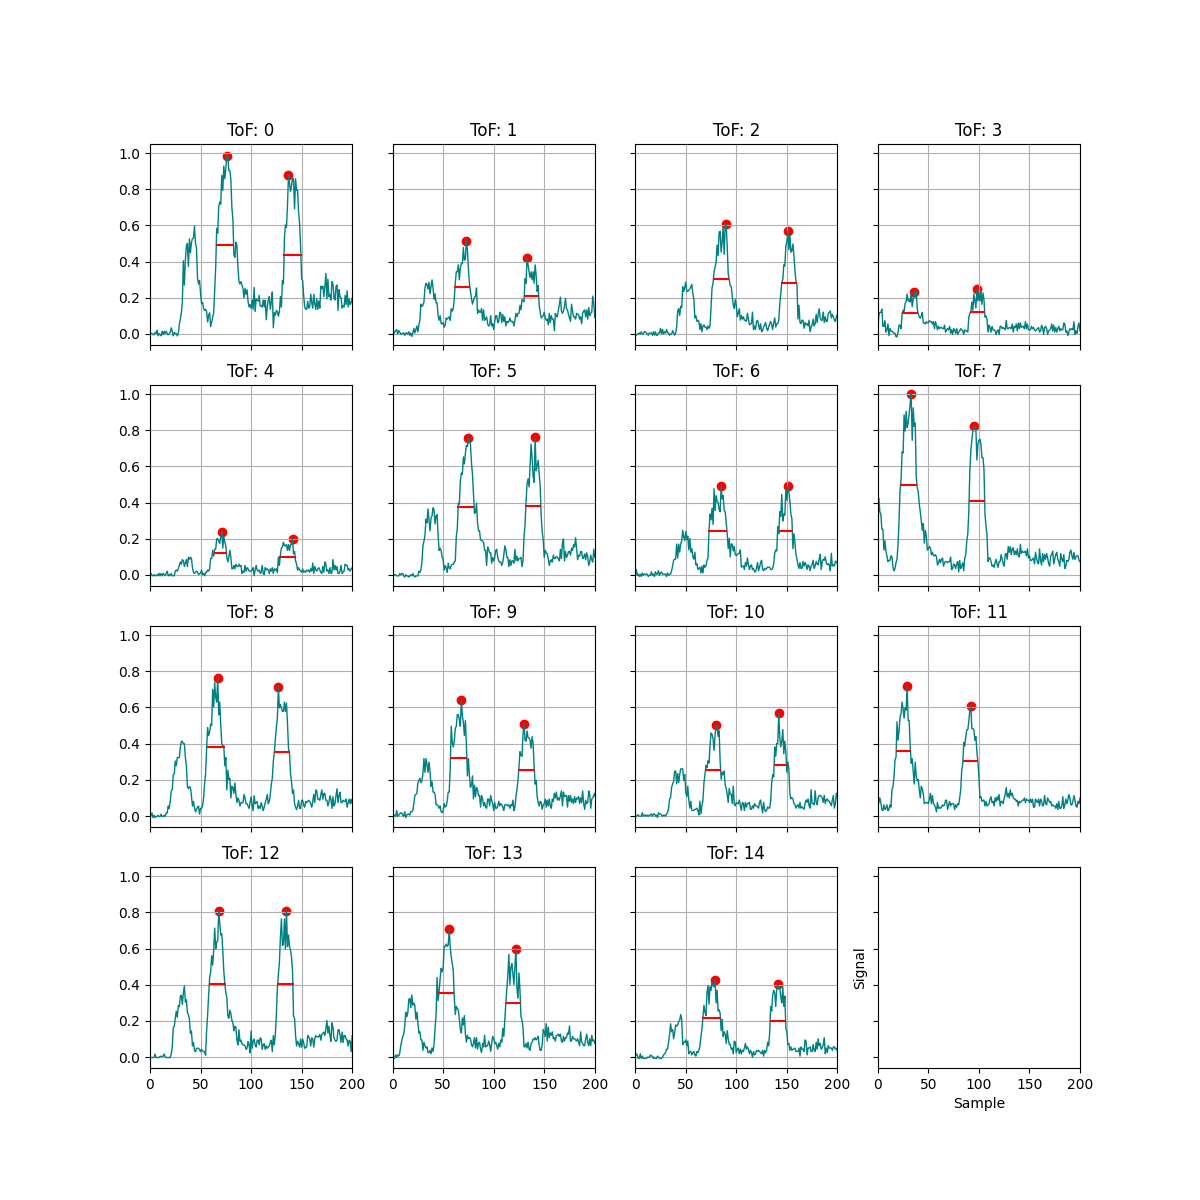

In [276]:
%matplotlib widget
results = ToFPipeline.PeakFinder(data.data).stack().normalize().process(threshold=0.01,peakNo=1,roi=[0,200],minWidth=False,symmetric=False).dataframe().plot(logScale=False,xmin=0,xmax=200)

In [277]:
ToFPipeline.AuxFunc(results.results).addData(data.angles, key="Angles", axis="detector")
import pandas as pd
setPhotonEnergy = [1300]
runs = runNo
setEnergyRun = {"daq_run": runs, "Photon Energy": setPhotonEnergy}
runsPhotonEnergy = pd.DataFrame(setEnergyRun)
merge = pd.merge(data.data["trainId"].to_dataframe(),runsPhotonEnergy, on="daq_run", how="left")
merge=merge[merge["pulseId"]==0]
trim=merge[["trainId","daq_run","Photon Energy"]]
trim = trim.loc[:,~trim.columns.duplicated()]
ToFPipeline.AuxFunc(results.results).addData(trim)


In [278]:
import numpy as np
def computeCorr(theta,I, Plin, phi=0, beta=2):
    return I/(1 + (beta / 4) * (1 + 3 * Plin * np.cos(2 * (theta - phi))))

In [279]:
def computePlin(theta, I0, I1, beta1, beta2, phi=0):
    return (4 / (3 * np.cos(2*(theta - phi)))) * ((I1 * (1 + beta1/4) - I0 * (1 + beta2/4)) / (I0 * beta2 - I1 * beta1))

In [280]:
# Separate peaks into different columns
peak0 = results.results[results.results['peakNo']==0].set_index(['detector', 'trainId', 'pulseId'])
peak1 = results.results[results.results['peakNo']==1].set_index(['detector', 'trainId', 'pulseId'])

# Merge on common indices
merged = results.results.merge(
    peak0[['height']].rename(columns={'height': 'I0'}),
    left_on=['detector', 'trainId', 'pulseId'],
    right_index=True,
    how='left'
).merge(
    peak1[['height']].rename(columns={'height': 'I1'}),
    left_on=['detector', 'trainId', 'pulseId'],
    right_index=True,
    how='left'
)

# Now compute Plin with aligned data
merged['Plin'] = computePlin(
    theta=merged['Angles'],
    I0=merged['I0'],
    I1=merged['I1'],
    beta1=0,
    beta2=1.357
)

In [281]:
merged["Transmission coefficent"] = computeCorr(
    merged['Angles'],merged['I0'],
    merged['Plin'],phi=0,beta=1.357)
corr_calc = merged[merged['peakNo']==0][["detector","Photon Energy","Transmission coefficent"]].reset_index()


In [282]:
importlib.reload(ToFPipeline)
ToFPipeline.GlobalConfig.load("config.yaml")

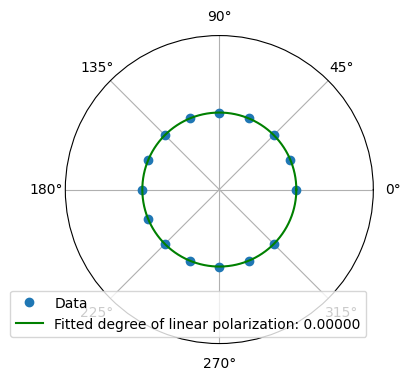

(array([ 2.00560163e-10, -1.64655799e-01,  1.00000000e+00]),
 array([[3.35203104e-21, 0.00000000e+00, 1.52464101e-22],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.52464101e-22, 0.00000000e+00, 9.28421619e-22]]))

In [ ]:
beta=2
calib = ToFPipeline.Calibrate(results.results).transmission(peakNo=1,setBeta=beta,setPlin=0.00,setPhi=0).transmissionParam
ToFPipeline.Fitter(results.results).pol(transParam=calib,peakNo=1,beta=beta)

In [296]:
import pandas as pd
from io import StringIO
rawdf = pd.read_csv(StringIO(raw), sep="|", skiprows=1).dropna().astype({"Photon Energy":int,"daq_run":int,"Ugap":float,"Ushift":float})
rawdf = rawdf[["daq_run","Photon Energy","Ugap","Ushift"]]

Random trainId: 2247, pulseId: 0


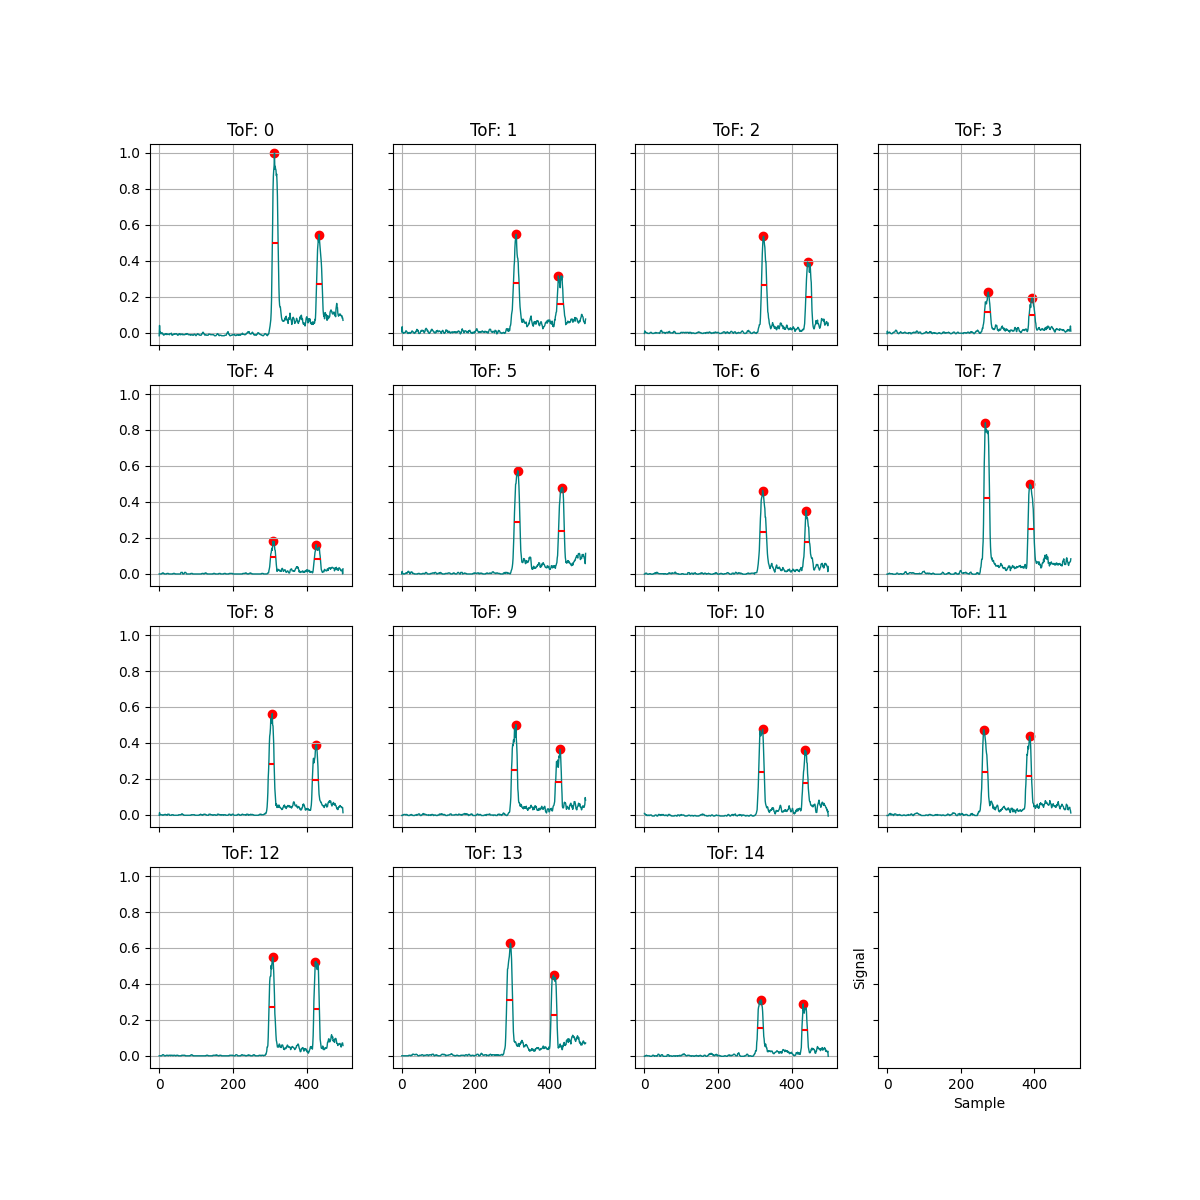

In [297]:
%matplotlib widget
data = ToFPipeline.NXSLoader("data").load(runNumbers=[2247],roi=[0,500]).defaultPreprocessing(baselineRegion=[0,10],ToF=list(range(15)))
results = ToFPipeline.PeakFinder(data.data).stack().smooth(windowSize=5).normalize().process(threshold=0.01,peakNo=1,roi=[None,500],minWidth=False,symmetric=False).dataframe().plot(logScale=False,xmin=None,xmax=None)

In [298]:
%matplotlib inline
import numpy as np
values=[]
error=[]
energies=[]
daq_run=[]
for i in rawdf["daq_run"].unique():
    runNo = i
    setPhotonEnergy = rawdf[rawdf["daq_run"]==runNo]["Photon Energy"].values
    data = ToFPipeline.NXSLoader("data").load(runNumbers=[runNo],roi=[200,500]).defaultPreprocessing(baselineRegion=[0,10],ToF=list(range(15)))
    results = ToFPipeline.PeakFinder(data.data).stack().smooth(windowSize=5).normalize().process(threshold=0.01,peakNo=1,roi=[None,500],minWidth=False,symmetric=False).dataframe()#.plot(logScale=False,xmin=None,xmax=None)
    ToFPipeline.AuxFunc(results.results).addData(data.angles, key="Angles", axis="detector")
    runs = runNo
    setEnergyRun = {"daq_run": runs, "Photon Energy": setPhotonEnergy}
    runsPhotonEnergy = pd.DataFrame(setEnergyRun)
    merge = pd.merge(data.data["trainId"].to_dataframe(),runsPhotonEnergy, on="daq_run", how="left")
    merge=merge[merge["pulseId"]==0]
    trim=merge[["trainId","daq_run","Photon Energy"]]
    trim = trim.loc[:,~trim.columns.duplicated()]
    ToFPipeline.AuxFunc(results.results).addData(trim)
    popt,pcov = ToFPipeline.Fitter(results.results).pol(calib,peakNo=1,beta=2,plot=False)
    values.append(popt)
    perr = np.sqrt(np.diag(pcov))
    error.append(perr)
    energies.append(setPhotonEnergy[0])
    daq_run.append(runNo)
    print(f"Completed run {runNo}")
values=pd.DataFrame(values, columns=["PLin","phi","scale"])
values["Photon Energy"]=energies
values["daq_run"]=daq_run
error=pd.DataFrame(error, columns=["PLin_err","phi_err","scale_err"])
values["PLin_err"]=error["PLin_err"]
values["phi_err"]=error["phi_err"]



Completed run 2119
Completed run 2120
Completed run 2121
Completed run 2122
Completed run 2123
Completed run 2124
Completed run 2125
Completed run 2126
Completed run 2127
Completed run 2128
Completed run 2129
Completed run 2130
Completed run 2131
Completed run 2132
Completed run 2133
Completed run 2134
Completed run 2135
Completed run 2136
Completed run 2137
Completed run 2138
Completed run 2139
Completed run 2140
Completed run 2141
Completed run 2142
Completed run 2143
Completed run 2144
Completed run 2145
Completed run 2146
Completed run 2147
Completed run 2148
Completed run 2149
Completed run 2150
Completed run 2152
Completed run 2153
Completed run 2154
Completed run 2155
Completed run 2156
Completed run 2157
Completed run 2158
Completed run 2159
Completed run 2160
Completed run 2161
Completed run 2162
Completed run 2163
Completed run 2164
Completed run 2165
Completed run 2166
Completed run 2167
Completed run 2168
Completed run 2169
Completed run 2170
Completed run 2171
Completed ru

In [299]:
runTable = rawdf[["daq_run","Ugap","Ushift"]]
complete = values.merge(runTable, on="daq_run")

<Figure size 1200x1200 with 0 Axes>

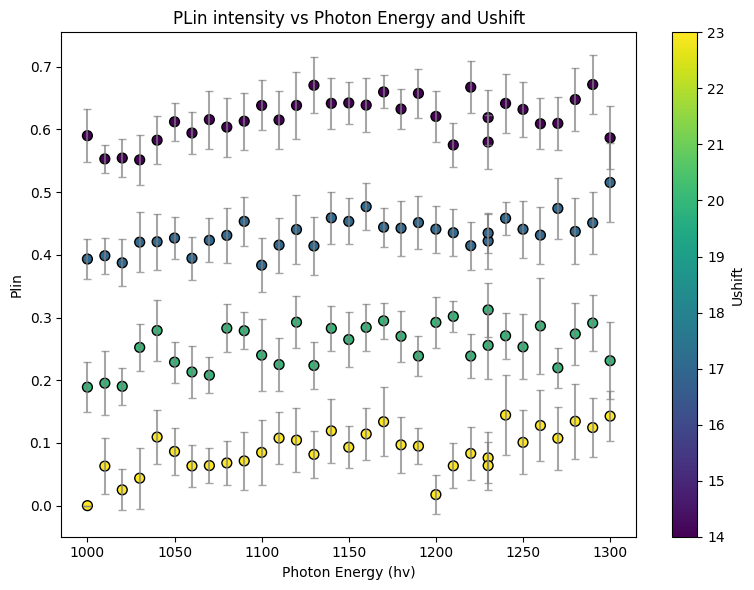

In [300]:
import matplotlib.pyplot as plt
plt.clf()
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    complete["Photon Energy"],          # x-axis
    complete["PLin"],      # y-axis
    c=complete["Ushift"],     # color = PL intensity
    cmap="viridis",    # choose any colormap
    s=50,              # marker size
    edgecolor="k"      # optional, black edge for clarity
)
plt.errorbar(
    complete["Photon Energy"],
    complete["PLin"],
    yerr=complete["PLin_err"],
    fmt='none',
    ecolor='gray',
    alpha=0.7,
    capsize=3
)

ax.set_xlabel("Photon Energy (hv)")
ax.set_ylabel("Plin")
ax.set_title("PLin intensity vs Photon Energy and Ushift")
#ax.invert_xaxis()  # common in spectroscopy

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Ushift")
plt.tight_layout()
plt.show()



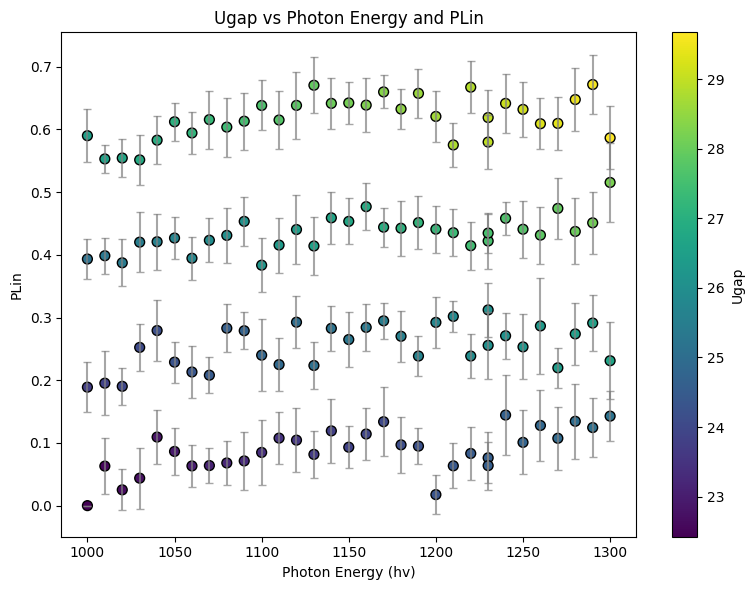

In [301]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    complete["Photon Energy"],          # x-axis
    complete["PLin"],      # y-axis
    c=complete["Ugap"],     # color = PL intensity
    cmap="viridis",    # choose any colormap
    s=50,              # marker size
    edgecolor="k"      # optional, black edge for clarity
)
plt.errorbar(
    complete["Photon Energy"],
    complete["PLin"],
    yerr=complete["PLin_err"],
    fmt='none',
    ecolor='gray',
    alpha=0.7,
    capsize=3
)

ax.set_xlabel("Photon Energy (hv)")
ax.set_ylabel("PLin")
ax.set_title("Ugap vs Photon Energy and PLin")
#ax.invert_xaxis()  # common in spectroscopy

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Ugap")
plt.tight_layout()
plt.show()

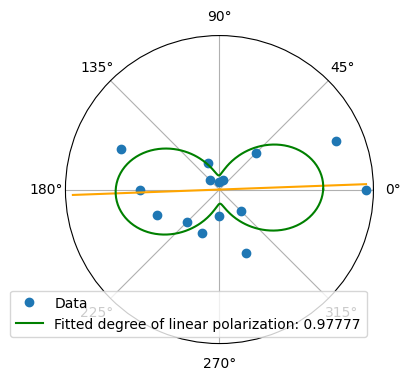

(array([0.97777267, 0.03679913, 1.6590251 ]),
 array([[ 0.065598  , -0.00082006, -0.0233797 ],
        [-0.00082006,  0.01435193, -0.00193837],
        [-0.0233797 , -0.00193837,  0.04521755]]))

In [266]:
import pandas as pd
data = ToFPipeline.NXSLoader("data").load(runNumbers=[1999]).defaultPreprocessing(baselineRegion=[1800,1850])
results = ToFPipeline.PeakFinder(data.data).stack().normalize().smooth(windowSize=4).process(threshold=0.01,peakNo=1,roi=[200,400],minWidth=False,symmetric=False).dataframe()#.plot(logScale=False,xmin=200,xmax=400)
ToFPipeline.AuxFunc(results.results).addData(data.angles, key="Angles", axis="detector")
setPhotonEnergy = [1000]
runs = runNo
setEnergyRun = {"daq_run": runs, "Photon Energy": setPhotonEnergy}
runsPhotonEnergy = pd.DataFrame(setEnergyRun)
merge = pd.merge(data.data["trainId"].to_dataframe(),runsPhotonEnergy, on="daq_run", how="left")
merge=merge[merge["pulseId"]==0]
trim=merge[["trainId","daq_run","Photon Energy"]]
trim = trim.loc[:,~trim.columns.duplicated()]
ToFPipeline.AuxFunc(results.results).addData(trim)
ToFPipeline.Fitter(results.results).pol(transParam=None,peakNo=1,beta=1.4)